# Problema de las 8 reinas

### Juan Daniel Rangel Avila


Este problema consiste  en encontrar un tablero de ajedrez donde colques ocho reinas simultaneamennte sin que se ataquen entre  si nignuna de ellas.


Las reinas se peuden atacar de las siguientes formas: forma de "+" y forma de  "x".

"+" sobre la misma columna donde etsa de arriba o abajo, de la misma forma sobre su misma fila, ya sea izquierda o derecha.

"x" sobre las diagonales, la diagonal en cualquier direccion, arriba derecha, arriba izquierda, abajo izquierda y abajo derecha

El conjunto de reinas se representa como dos vectores ($X$ y $Y$) de tamaño $N$; que guardan sus posiciones en Horizontal y Vertical, siendo la tupla ordenada una reina.

$X = [x_1,x_2,...,x_n]$, 
$Y = [y_1,y_2,...,y_n]$ $\implies$
$Reina_1 = (x_1,y_2),...,Reina_N = (x_n,y_n)$

La funcion onjetivo recibe ambos vectores y determina cuales son las reinas que estan en conflicto retornando el valor $0$ si no hay ninguna reina en conflicto, siendo este nuestro optimo global, 2 si hay al menos 2 en conflicto, y de ahi los numeros pueden crecer de manera discreta de uno en uno.

La solucion inicial es un sample de numeros de 1 hasta N, garantizando que jamas esten dos reinas en la misma columna o fila.

La MetaHeuristica Propuesta en este proyecto es "simulated annealing" que recibe el tamaño del tablero, la temperatura inicial y final.

la generacion de vecinos toma uno de los dos vectores al azar e intercambia algun valor con otro dentro del mismo para forzar un cambio, al pasar por la funcion objetivo esta culcula su nuevo valor



## import necesarios:

In [1]:
import random as r
import numpy as np
from joblib import Parallel, delayed

## Funcion Objetivo:

se cuenta cuantas reinas estan en  conflicto, naturalmente se requiere minimizar esta funcion, siendo  el optimo global 0

In [2]:
def f(x, y, n:int):
    matriz = [(x[i], y[i]) for i in range(n)]

    # función auxiliar para cada reina
    def check_diagonals(i):
        a, b = x[i], y[i]
        cont_local = []
        for j in range(1, n, 1):
            jj, menosjj, jmenosj, menosjmenosj = (a+j,b+j), (a-j,b+j), (a+j,b-j), (a-j,b-j)
            if jj in matriz: cont_local.append(jj)
            if menosjj in matriz: cont_local.append(menosjj)
            if jmenosj in matriz: cont_local.append(jmenosj)
            if menosjmenosj in matriz: cont_local.append(menosjmenosj)
        return cont_local

    # paralelizar el bucle con joblib
    results = Parallel(n_jobs=-1)(delayed(check_diagonals)(i) for i in range(n))

    # aplanar la lista de resultados
    cont = [pos for sublist in results for pos in sublist]

    return len(set(cont))  

## Solucion Inicial

In [3]:
def get_initial_solution(n:int):
    x=r.sample(range(0,n), n)
    y=r.sample(range(0,n), n)
    return x,y

In [4]:
n=8
x,y=get_initial_solution(n)
print(f"x = {x}")
print(f"y = {y}")

x = [2, 0, 6, 7, 5, 3, 4, 1]
y = [4, 1, 5, 3, 6, 7, 2, 0]


In [5]:
f(x,y,n)

8

## Vecinos

In [6]:
def get_neighbor(x, y, n:int):
    x_new = x[:]
    y_new = y[:]  
    if r.random() < 0.5:
        i, j = r.sample(range(n), 2)
        x_new[i], x_new[j] = x_new[j], x_new[i]
    else:
        i, j = r.sample(range(n), 2)
        y_new[i], y_new[j] = y_new[j], y_new[i]
    
    return x_new, y_new


In [7]:
get_neighbor(x, y, n)

([2, 0, 6, 7, 5, 3, 4, 1], [4, 1, 5, 0, 6, 7, 2, 3])

## Recocido  Simulado

In [8]:
def simulated_annealing(t_0, t_f, n:int):
    x = get_initial_solution(n)
    fx = f(*x, n)
    
    #print (f"Solucion inicial:\nx: {x[0]}\ny: {x[1]}\ncon f(x,y) = {fx}\n")
    
    xbest, fbest = x, fx

    t = t_0
    cont = 0
    while t > t_f:
        y = get_neighbor(*x, n)
        fy = f(*y, n)

        if fy <= fbest:
            xbest, fbest = y, fy
            if fbest == 0:
                break

        if fy <= fx or np.random.random() < np.exp( -(fy - fx)/t ):
            x, fx = y, fy
        cont += 1
        t *= 0.99
    #print(f"numero de iteraciones: {cont}\n")
    return xbest, fbest
    

## Visualizacion

In [9]:
import matplotlib.pyplot as plt

def dibujar_tablero(coordenadas, n:int):
    fig, ax = plt.subplots()

    # Dibujar cuadrícula blanca
    for x in range(n):
        for y in range(n):
            ax.add_patch(plt.Rectangle((x, y), 1, 1, fill=False, edgecolor="black"))

    # Dibujar las reinas como bolitas
    for (x, y) in coordenadas:
        ax.plot(x + 0.5, y + 0.5, "o", color="red", markersize=20)

    # Ajustes visuales
    ax.set_xlim(0, n)
    ax.set_ylim(0, n)
    ax.set_aspect("equal")
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.grid(False)
    plt.show()




In [10]:
n=150
(x,y),result = simulated_annealing(10000, 0.001, n)
print(f"Solucion final:\nx: {x}\ny: {y}\ncon f(x,y) = {result}")
matriz=[(x[i],y[i]) for i in range(n)]
#dibujar_tablero(matriz,n)

Solucion final:
x: [35, 54, 128, 44, 72, 21, 65, 117, 93, 100, 104, 58, 83, 89, 71, 15, 10, 62, 76, 34, 9, 109, 52, 70, 36, 48, 113, 53, 43, 29, 75, 90, 94, 115, 122, 22, 133, 66, 16, 102, 55, 147, 51, 6, 77, 129, 132, 26, 114, 27, 13, 111, 145, 143, 0, 7, 95, 101, 68, 119, 81, 69, 130, 79, 1, 140, 78, 134, 74, 4, 123, 47, 127, 12, 85, 33, 45, 99, 82, 23, 41, 141, 118, 5, 120, 11, 37, 46, 38, 73, 97, 138, 3, 112, 8, 17, 80, 91, 96, 136, 144, 42, 98, 59, 149, 84, 56, 142, 110, 108, 116, 121, 86, 125, 60, 24, 105, 14, 103, 61, 137, 32, 87, 148, 131, 18, 146, 39, 92, 50, 30, 25, 57, 28, 139, 64, 106, 20, 31, 67, 40, 88, 49, 124, 107, 19, 63, 135, 2, 126]
y: [60, 96, 84, 110, 136, 114, 22, 128, 87, 61, 51, 3, 66, 35, 118, 63, 122, 2, 6, 123, 21, 37, 69, 38, 58, 52, 42, 33, 19, 4, 132, 137, 49, 144, 17, 126, 135, 73, 16, 112, 40, 91, 71, 100, 119, 50, 44, 140, 28, 11, 31, 15, 131, 0, 97, 67, 1, 48, 55, 43, 30, 56, 92, 85, 103, 77, 20, 45, 101, 125, 74, 139, 120, 80, 93, 98, 115, 124, 62, 11

## M runs

In [11]:
def m_runs(m,t,t_f,n:int):
    runs=[]
    for _ in range(m):
        runs.append(simulated_annealing(t, t_f, n))
    f_runs = [r[1] for r in runs]
    mean = np.mean(f_runs)
    std = np.std(f_runs)
    best = runs[np.argmin(f_runs)]
    worst = runs[np.argmax(f_runs)]
    runs.sort(key=lambda x: x[1])
    median = runs[m//2]
    return mean, std, best, worst, median

Despues de revisar varios espacios de busqueda, se nota que para el problema clasico de N=8 este problema lo resuelve en fracciones de segundos, de hehco, con N = 15 lo resuelve en 0.3segs lo cual es casi instantaneo sabiendo que, el numero de tableros totales es 15! y que el tiempo total de revisar todos los tableros suponiendo que tarda 0.01segs en revisar una reina, la fuerza bruta tardaria varias centenas de años en revisarlos.

volviendo al punto, naturalmente cuesta mas y mas encontrar un optimo global en tableros mas y mas grandes, abajo dejo algunos resultados de distintas pruebas.

In [13]:
n=150
(x,y),result = simulated_annealing(10000, 0.001, n)
print(f"Solucion final:\nx: {x}\ny: {y}\ncon f(x,y) = {result}")
matriz=[(x[i],y[i]) for i in range(n)]
#dibujar_tablero(matriz,n)

Solucion final:
x: [9, 93, 81, 126, 119, 50, 36, 82, 31, 47, 127, 95, 71, 148, 99, 131, 0, 142, 91, 68, 105, 35, 149, 87, 66, 19, 107, 80, 29, 88, 46, 96, 18, 110, 65, 12, 84, 108, 21, 147, 75, 53, 64, 113, 56, 48, 67, 40, 55, 101, 73, 34, 78, 37, 90, 132, 98, 97, 106, 120, 137, 8, 15, 130, 102, 28, 143, 20, 6, 61, 4, 41, 49, 103, 59, 114, 104, 24, 26, 111, 77, 33, 7, 32, 5, 54, 112, 38, 45, 30, 145, 146, 136, 16, 17, 92, 109, 125, 76, 58, 52, 116, 43, 22, 135, 25, 1, 139, 44, 39, 10, 141, 85, 72, 42, 63, 118, 57, 51, 129, 115, 2, 122, 144, 3, 133, 62, 140, 117, 74, 14, 138, 60, 134, 23, 27, 83, 94, 11, 89, 86, 79, 100, 128, 121, 124, 69, 13, 123, 70]
y: [115, 28, 47, 14, 48, 73, 116, 65, 87, 68, 69, 12, 90, 60, 105, 51, 72, 107, 127, 106, 32, 26, 147, 13, 88, 130, 56, 148, 4, 46, 0, 40, 83, 29, 20, 111, 133, 54, 131, 39, 38, 92, 112, 145, 74, 58, 64, 91, 42, 37, 119, 137, 31, 132, 80, 23, 75, 139, 120, 21, 76, 86, 82, 16, 117, 113, 10, 50, 144, 7, 118, 143, 5, 104, 122, 27, 55, 59, 10

Solucion final:
x: [2, 48, 28, 4, 25, 22, 31, 37, 19, 41, 15, 36, 45, 5, 21, 16, 35, 18, 23, 47, 14, 30, 32, 17, 1, 12, 44, 39, 40, 3, 29, 9, 6, 34, 33, 26, 7, 38, 20, 11, 10, 42, 8, 24, 46, 27, 13, 49, 0, 43]
y: [43, 27, 12, 21, 49, 35, 4, 29, 9, 45, 26, 18, 28, 5, 31, 34, 24, 40, 14, 17, 8, 39, 6, 22, 7, 15, 44, 10, 41, 0, 48, 47, 37, 33, 13, 46, 3, 25, 1, 23, 38, 19, 16, 20, 32, 2, 42, 11, 30, 36]
con f(x,y) = 4


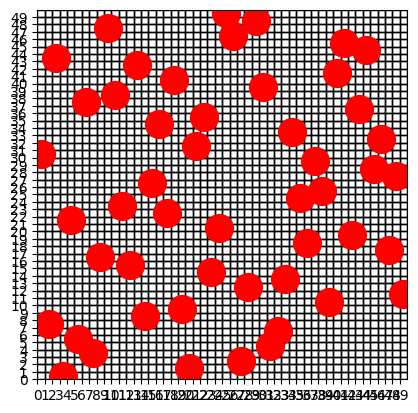

In [14]:
n=50
(x,y),result = simulated_annealing(10000, 0.001, n)
print(f"Solucion final:\nx: {x}\ny: {y}\ncon f(x,y) = {result}")
matriz=[(x[i],y[i]) for i in range(n)]
dibujar_tablero(matriz,n)

In [15]:
n=25
(x,y),result = simulated_annealing(10000, 0.001, n)
print(f"Solucion final:\nx: {x}\ny: {y}\ncon f(x,y) = {result}")
matriz=[(x[i],y[i]) for i in range(n)]
#dibujar_tablero(matriz,n)

Solucion final:
x: [3, 16, 12, 10, 13, 9, 24, 22, 11, 8, 19, 23, 17, 15, 20, 18, 5, 4, 21, 14, 6, 2, 1, 7, 0]
y: [7, 21, 0, 22, 3, 5, 18, 16, 20, 10, 4, 12, 9, 6, 14, 11, 15, 24, 1, 13, 19, 17, 23, 2, 8]
con f(x,y) = 3


Solucion final:
x: [9, 3, 14, 6, 10, 5, 11, 13, 0, 4, 2, 8, 7, 1, 12]
y: [2, 12, 11, 10, 4, 7, 6, 9, 5, 3, 8, 0, 14, 13, 1]
con f(x,y) = 2


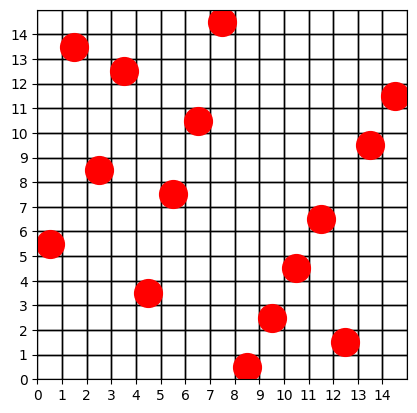

In [16]:
n=15
(x,y),result = simulated_annealing(10000, 0.001, n)
print(f"Solucion final:\nx: {x}\ny: {y}\ncon f(x,y) = {result}")
matriz=[(x[i],y[i]) for i in range(n)]
dibujar_tablero(matriz,n)

Solucion final:
x: [6, 2, 5, 3, 1, 4, 0, 7]
y: [2, 7, 0, 1, 5, 6, 3, 4]
con f(x,y) = 0


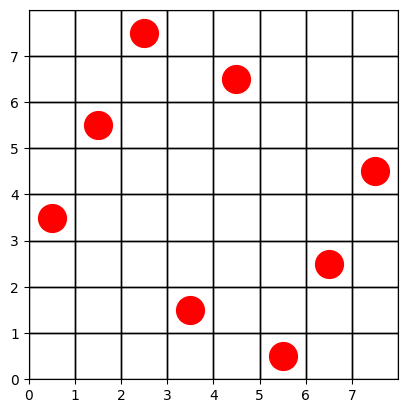

In [17]:
n=8
(x,y),result = simulated_annealing(10000, 0.001, n)
print(f"Solucion final:\nx: {x}\ny: {y}\ncon f(x,y) = {result}")
matriz=[(x[i],y[i]) for i in range(n)]
dibujar_tablero(matriz,n)

Solucion final:
x: [2, 0, 1, 3]
y: [3, 2, 0, 1]
con f(x,y) = 0


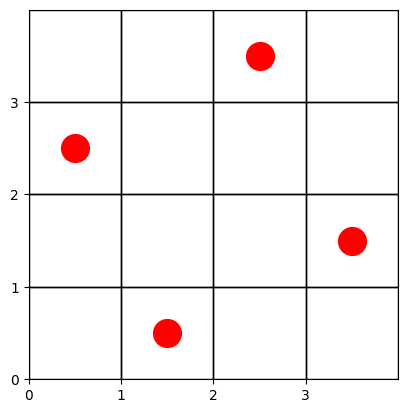

In [18]:
n=4
(x,y),result = simulated_annealing(10000, 0.001, n)
print(f"Solucion final:\nx: {x}\ny: {y}\ncon f(x,y) = {result}")
matriz=[(x[i],y[i]) for i in range(n)]
dibujar_tablero(matriz,n)

en general este algoritmo es una prueba de la eficiencia de esta metaheuristica que resuelve en general bastante bien y bastante rapido el problema hasta 15 reinas, despues ceusta abstante trabajo que llegue a un optimo global, ya que los tableros son mas dificil de resolver y los optimos locales son mucho ams abundantes

In [19]:
n=50
m=50
cosas = m_runs(m,10000, 0.001, n)
print(f"Media: {cosas[0]}\nStd: {cosas[1]}\nMejor resultado: {cosas[2]}\nPeor resultado: {cosas[3]}\nMediana: {cosas[4]}")

Media: 4.96
Std: 2.0195048898182937
Mejor resultado: (([2, 23, 35, 33, 11, 19, 41, 44, 29, 1, 17, 46, 31, 48, 8, 49, 13, 15, 0, 36, 37, 3, 20, 6, 4, 25, 9, 7, 38, 22, 39, 28, 34, 45, 43, 26, 32, 27, 14, 24, 16, 12, 42, 47, 10, 30, 5, 18, 40, 21], [33, 1, 2, 17, 28, 13, 47, 40, 41, 15, 35, 21, 5, 29, 46, 26, 4, 30, 0, 7, 9, 27, 3, 8, 12, 23, 22, 14, 48, 43, 18, 10, 37, 11, 38, 16, 31, 24, 39, 25, 45, 32, 34, 36, 19, 49, 42, 44, 20, 6]), 2)
Peor resultado: (([17, 46, 47, 34, 4, 1, 32, 35, 11, 39, 6, 22, 14, 24, 20, 13, 49, 25, 0, 41, 23, 16, 48, 15, 38, 10, 5, 31, 33, 28, 36, 19, 12, 8, 2, 3, 21, 26, 42, 37, 18, 27, 7, 9, 44, 45, 30, 40, 43, 29], [5, 0, 38, 48, 45, 24, 37, 46, 20, 29, 41, 17, 12, 32, 19, 42, 25, 10, 39, 47, 4, 26, 9, 33, 27, 31, 35, 44, 3, 15, 30, 2, 40, 11, 28, 34, 8, 6, 21, 23, 43, 14, 7, 13, 36, 22, 49, 18, 1, 16]), 10)
Mediana: (([37, 25, 34, 28, 17, 4, 45, 31, 3, 30, 0, 6, 39, 5, 12, 18, 44, 10, 8, 26, 38, 40, 7, 47, 11, 49, 22, 43, 1, 27, 16, 35, 42, 21, 2, 9, 19, 

In [20]:
n=25
m=50
cosas = m_runs(m,10000, 0.001, n)
print(f"Media: {cosas[0]}\nStd: {cosas[1]}\nMejor resultado: {cosas[2]}\nPeor resultado: {cosas[3]}\nMediana: {cosas[4]}")

Media: 1.42
Std: 1.06
Mejor resultado: (([0, 14, 22, 9, 17, 18, 10, 6, 13, 23, 4, 11, 16, 3, 5, 12, 2, 7, 8, 19, 21, 1, 15, 20, 24], [13, 8, 18, 16, 10, 15, 21, 4, 2, 14, 5, 17, 0, 20, 19, 22, 1, 7, 3, 23, 9, 6, 24, 12, 11]), 0)
Peor resultado: (([4, 15, 13, 20, 9, 5, 11, 3, 23, 16, 18, 22, 21, 2, 0, 24, 8, 7, 14, 17, 12, 19, 10, 1, 6], [13, 16, 6, 7, 20, 1, 11, 18, 12, 2, 10, 24, 5, 21, 4, 23, 3, 17, 19, 15, 0, 22, 9, 8, 14]), 3)
Mediana: (([5, 10, 8, 15, 14, 23, 19, 24, 1, 9, 12, 4, 3, 17, 16, 2, 11, 13, 6, 22, 0, 7, 21, 20, 18], [20, 8, 4, 22, 13, 17, 9, 2, 23, 10, 18, 16, 12, 6, 19, 15, 21, 1, 3, 14, 5, 7, 0, 24, 11]), 2)


In [21]:
n=15
m=50
cosas = m_runs(m,10000, 0.001, n)
print(f"Media: {cosas[0]}\nStd: {cosas[1]}\nMejor resultado: {cosas[2]}\nPeor resultado: {cosas[3]}\nMediana: {cosas[4]}")

Media: 0.6
Std: 0.9165151389911679
Mejor resultado: (([0, 2, 3, 11, 6, 9, 5, 14, 1, 8, 13, 4, 7, 12, 10], [10, 9, 2, 4, 12, 13, 14, 6, 3, 8, 11, 5, 1, 0, 7]), 0)
Peor resultado: (([14, 11, 0, 7, 6, 1, 5, 3, 2, 12, 8, 10, 9, 4, 13], [5, 9, 7, 4, 2, 12, 13, 6, 1, 0, 8, 11, 14, 10, 3]), 2)
Mediana: (([13, 0, 1, 2, 11, 14, 8, 5, 7, 4, 6, 3, 9, 10, 12], [11, 3, 7, 2, 1, 9, 5, 13, 12, 6, 10, 14, 0, 4, 8]), 0)


In [22]:
n=8
m=50
cosas = m_runs(m,10000, 0.001, n)
print(f"Media: {cosas[0]}\nStd: {cosas[1]}\nMejor resultado: {cosas[2]}\nPeor resultado: {cosas[3]}\nMediana: {cosas[4]}")

Media: 0.0
Std: 0.0
Mejor resultado: (([7, 4, 5, 2, 1, 3, 6, 0], [3, 2, 0, 1, 6, 5, 7, 4]), 0)
Peor resultado: (([7, 4, 5, 2, 1, 3, 6, 0], [3, 2, 0, 1, 6, 5, 7, 4]), 0)
Mediana: (([1, 5, 4, 2, 0, 6, 3, 7], [1, 0, 5, 4, 3, 2, 7, 6]), 0)


In [23]:
n=4
m=50
cosas = m_runs(m,10000, 0.001, n)
print(f"Media: {cosas[0]}\nStd: {cosas[1]}\nMejor resultado: {cosas[2]}\nPeor resultado: {cosas[3]}\nMediana: {cosas[4]}")

Media: 0.0
Std: 0.0
Mejor resultado: (([1, 0, 2, 3], [3, 1, 0, 2]), 0)
Peor resultado: (([1, 0, 2, 3], [3, 1, 0, 2]), 0)
Mediana: (([0, 2, 1, 3], [2, 3, 0, 1]), 0)
